In [ ]:
import sys
from pathlib import Path

_gpt4o_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    _nested = base / "After_PT_Removal" / "GPT4o" / "paths.py"
    if _nested.is_file() and "GPT4O_ROOT" in _nested.read_text(encoding="utf-8", errors="ignore"):
        _gpt4o_root = _nested.parent
        break
    _direct = base / "paths.py"
    if _direct.is_file() and "GPT4O_ROOT" in _direct.read_text(encoding="utf-8", errors="ignore"):
        _gpt4o_root = _direct.parent
        break
if _gpt4o_root is None:
    raise RuntimeError(
        "Could not find After_PT_Removal/GPT4o/paths.py — set the kernel cwd to NeuRIPS25 (repo root)."
    )
sys.path.insert(0, str(_gpt4o_root))
import paths


In [1]:
%pip install matplotlib
%pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.3/999.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 133.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
      Successfully uninstalled numpy-2.0.2━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.3.0 requires daal==2021.2.3, which is not installed.
krippendorff 0.8.1 requires numpy<3,>=1.21, but you have numpy 1.20.3 which is incompatible.

[notice] A new release of pip is av

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prefer physician-eval aggregate: aggregate_physician_subset_evals.py --result-report
_phys_rr = paths.TABLES / "PhysicianEval_Result_Report.csv"
USE_PHYSICIAN_SUBSET_LABELS = _phys_rr.is_file()
df = pd.read_csv(_phys_rr if USE_PHYSICIAN_SUBSET_LABELS else paths.TABLES / "Result_Report.csv")

In [3]:
# Debug: Print all unique labeler names
print("Unique labelers in dataset:")
print(df['Low+Irr Labelers'].unique())
print("\nLabelers defined in color dict:")
print(list(labeler_colors.keys()))

# Add this at the beginning of your script, right after loading the dataframe
df['Low+Irr Labelers'] = df['Low+Irr Labelers'].str.strip()
print(df['Low+Irr Labelers'].unique())

df['Base Model'] = df['Base Model'].str.strip()
print(df['Base Model'].unique())

Unique labelers in dataset:
['Original Accuracy' 'Trainee Removed (248 QAs)' 'Trainee Removed'
 'Qwen-14B Removed' 'Qwen-72B Removed' 'Llama-70b Removed'
 'GPT-4o Removed' 'GPT5 Removed' 'GPT5 Removed ']

Labelers defined in color dict:


NameError: name 'labeler_colors' is not defined

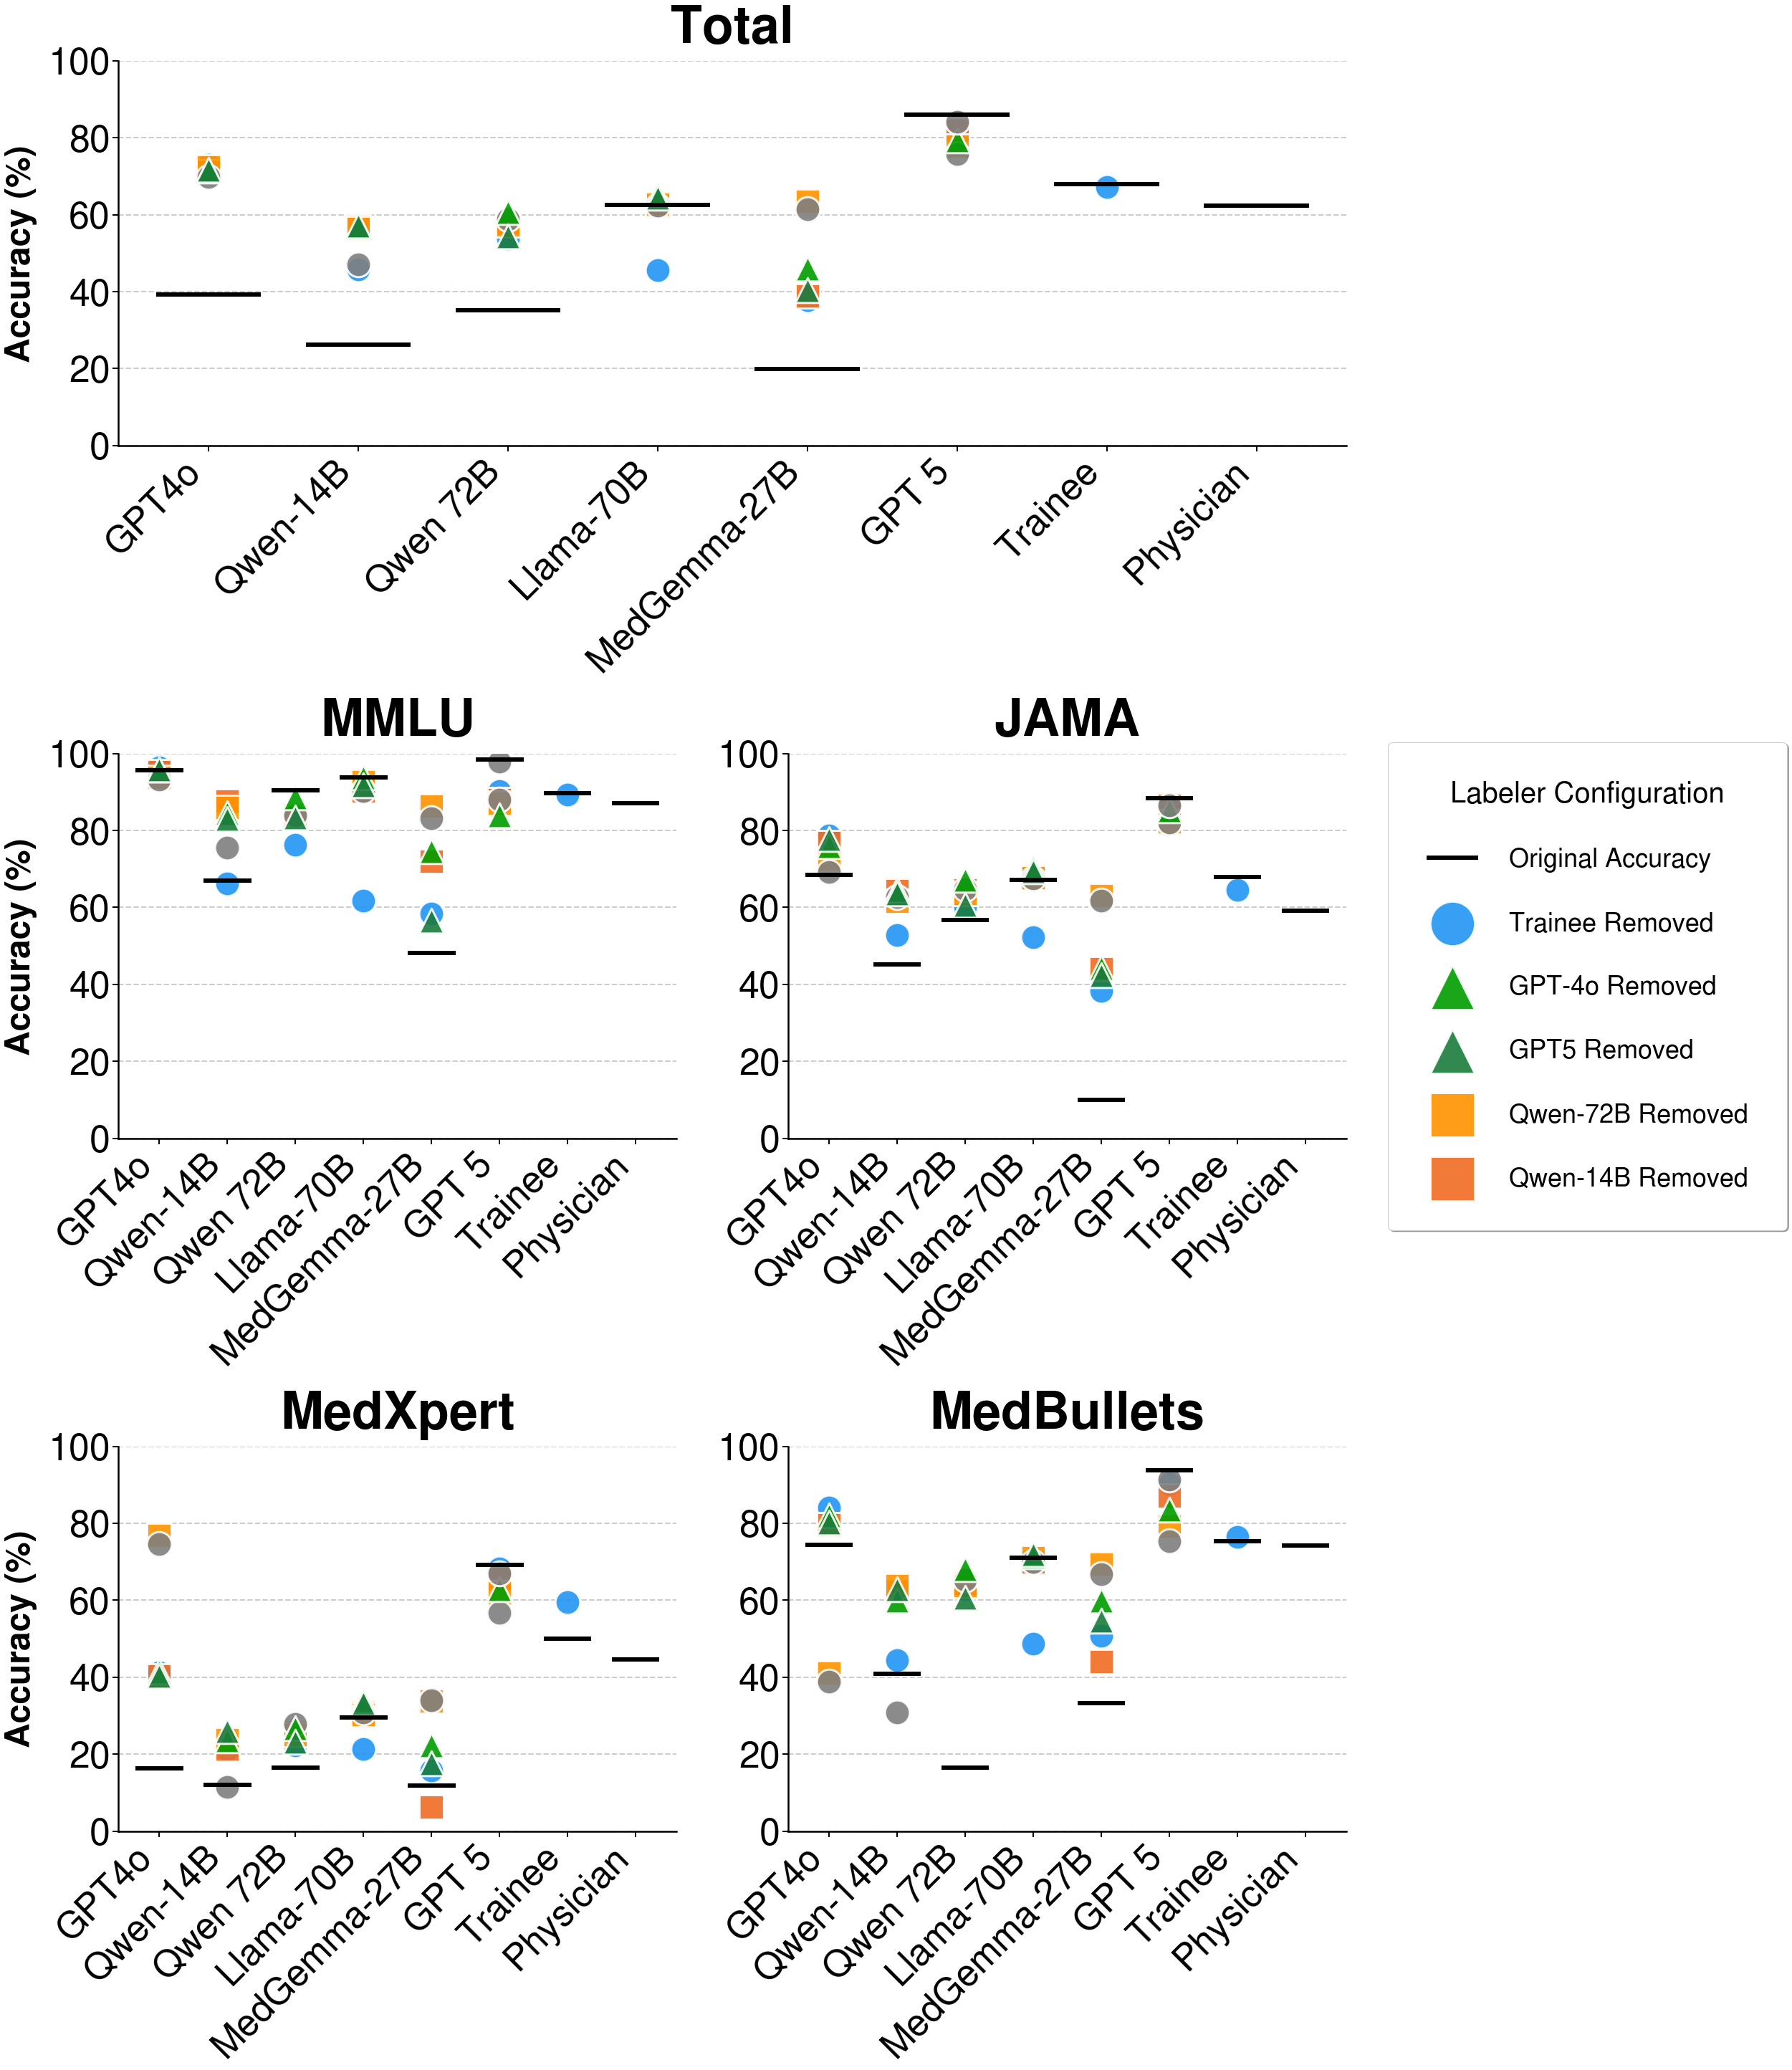

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set style for better aesthetics
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Define colors for each "Low+Irr Labelers" entry
labeler_colors = {
    'Original Accuracy': '#000000',  # Black for baseline
    'Trainee Removed': '#2196F3',
    'Trainee Removed (248 QAs)': '#2196F3',
#     'Qwen-72 Removed': '#ff9200',
    'Qwen-14B Removed': '#f16c23',
    'Qwen-72B Removed': '#ff9200',
    'Llama-70B Removed': '#f9AE78',
    'MedGemma-27B': '#ECB66C',
    'GPT-4o Removed': '#009d00',
    'GPT5 Removed': '#1b7c3d',
}

# Define marker shapes for different labelers
labeler_markers = {
    'Original Accuracy': None,  # Will be plotted as line
    'Trainee Removed': 'o',  # Circle
    'Trainee Removed (248 QAs)': 'o',  # Circle
#     'Qwen-72 Removed': 's',  # Square
    'Qwen-14B Removed': 's',  # Square
    'Qwen-72B Removed': 's',  # Square
    'Llama-70B Removed': 's',  # Square
    'MedGemma-27B Removed': 's',  # Square
    'GPT-4o Removed': '^',  # Triangle
    'GPT5 Removed': '^',  # Triangle
}

# Set up the plot with custom layout
fig = plt.figure(figsize=(28, 39))
gs = fig.add_gridspec(3, 2, hspace=0.8, wspace=0.2, 
                       height_ratios=[1, 1, 1])

# Create 5 subplots
axes = [
    fig.add_subplot(gs[0, :]),   # Top row, full width - Total
    fig.add_subplot(gs[1, 0]),   # Middle left - MMLU
    fig.add_subplot(gs[1, 1]),   # Middle right - Jama
    fig.add_subplot(gs[2, 0]),   # Bottom left - MedXpert
    fig.add_subplot(gs[2, 1]),   # Bottom right - Medbullets
]

# Define which column each subplot represents
columns = ['Total', 'MMLU', 'Jama', 'MedXpert', 'Medbullets']
titles = (['Total', '933', 'HardQA', 'Impossible', 'Mean (3 sub.)'] if USE_PHYSICIAN_SUBSET_LABELS else ['Total', 'MMLU', 'JAMA', 'MedXpert', 'MedBullets'])

# Base models to show on x-axis - REORDERED
    base_models = ['GPT4o', 'Qwen-14B', 'Qwen 72B', 'Llama-70B', 'MedGemma-27B', 'GPT 5', 'Trainee']

# Plot each subplot
for ax_idx, (ax, col, title) in enumerate(zip(axes, columns, titles)):
    x_positions = np.arange(len(base_models))
    
    # Track which labels we've added to legend
    added_labels = set()
    
    # For each base model, plot all its labeler variations
    for i, model in enumerate(base_models):
        # Get all rows for this base model
        model_data = df[df['Base Model'] == model]
        
        # Plot each labeler entry
        for _, row in model_data.iterrows():
            labeler = row['Low+Irr Labelers']
            value = row[col]
            color = labeler_colors.get(labeler, '#7f7f7f')
            
            # Only add label if we haven't seen this labeler yet
            label = labeler if labeler not in added_labels else ''
            if label:
                added_labels.add(labeler)
            
            # Plot Original Accuracy as a horizontal line instead of a dot
            if labeler == 'Original Accuracy':
                ax.plot([i - 0.35, i + 0.35], [value, value], 
                       color=color, linewidth=6, solid_capstyle='butt',
                       zorder=3, label=label)
            else:
                # Get the marker shape for this labeler
                marker = labeler_markers.get(labeler, 'o')
                
                # Plot other labelers as dots/triangles/squares with MUCH larger size
                ax.scatter(i, value, c=color, s=1200, alpha=0.9, 
                          marker=marker, edgecolors='white', linewidth=3, zorder=3,
                          label=label)
    
    # Formatting
    ax.set_xlim(-0.6, len(base_models) - 0.4)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(base_models, rotation=45, ha='right', fontsize=44, fontweight='500')
    
    # Only show y-axis label for left plots (index 0, 1, 3)
    if ax_idx in [0, 1, 3]:
        ax.set_ylabel('Accuracy (%)', fontsize=48, fontweight='bold', labelpad=15)
        
    ax.set_title(title, fontsize=72, fontweight='bold', pad=25)
    ax.grid(axis='y', alpha=0.4, linewidth=2, color='gray', linestyle='--', zorder=1)
    ax.grid(axis='x', alpha=0, zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=52, width=2, length=8, color='black')
    ax.tick_params(axis='x', labelsize=52, width=2, length=8, color='black')
    
    # Set y-axis limits - don't go over 100
    ax.set_ylim(0, 100)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Thicker black spines for left and bottom only
    ax.spines['left'].set_linewidth(2.5)
    ax.spines['left'].set_edgecolor('black')
    ax.spines['bottom'].set_linewidth(2.5)
    ax.spines['bottom'].set_edgecolor('black')

# Create unified legend outside the plots with better formatting
handles, labels = axes[0].get_legend_handles_labels()
# Remove duplicates
by_label = dict(zip(labels, handles))

# Reorder legend to put Original Accuracy first
legend_order = ['Original Accuracy', 'Trainee Removed', 'GPT-4o Removed', 
                'GPT5 Removed', 'Qwen-72B Removed', 'Qwen-14B Removed', 'Llama-70B Removed']
ordered_handles = []
ordered_labels = []
for label in legend_order:
    if label in by_label:
        ordered_labels.append(label)
        ordered_handles.append(by_label[label])

fig.legend(ordered_handles, ordered_labels, 
          loc='center left', bbox_to_anchor=(0.88, 0.5),
          fontsize=36, framealpha=1, markerscale=1.8,
          frameon=True, fancybox=True, shadow=True,
          title='Labeler Configuration', title_fontsize=40,
          labelspacing=1.5, borderpad=1.5, handletextpad=1.2)

plt.subplots_adjust(left=0.01, right=0.86, top=0.96, bottom=0.08)
plt.savefig(paths.FIGURES / 'MedPAIR_Result.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [5]:
# Add this right after loading your dataframe
print("Unique Base Models:")
print(df['Base Model'].unique())
print("\nData for GPT 5:")
print(df[df['Base Model'] == 'GPT 5'])
print("\nAll rows with 'Original Accuracy':")
print(df[df['Low+Irr Labelers'] == 'Original Accuracy'])

Unique Base Models:
['Trainee' 'Physician' 'GPT4o' 'GPT 5' 'Qwen-14B' 'Qwen 72B' 'Llama-70B'
 'MedGemma-27B']

Data for GPT 5:
   Base Model   Low+Irr Labelers  MMLU  Jama  MedXpert  Medbullets  Total  \
10      GPT 5  Original Accuracy  98.5  88.3      69.2        93.7   86.0   
11      GPT 5    Trainee Removed  90.2  84.4      68.2        90.3   82.2   
12      GPT 5   Qwen-14B Removed  88.1  86.6      65.7        87.0   81.8   
13      GPT 5   Qwen-72B Removed  87.1  82.3      61.9        79.2   77.7   
14      GPT 5  Llama-70b Removed  88.1  82.0      56.8        75.4   75.7   
15      GPT 5     GPT-4o Removed  83.9  85.2      62.9        83.6   79.3   
16      GPT 5      GPT5 Removed   97.9  86.6      67.0        91.3   84.2   

    MMLU_STD  JAMA_STD  MedXpert_STD  MedBullets_STD  Total_STD  
10      12.4      32.2          46.3            24.3       12.8  
11      29.9      36.4          46.6            29.6       10.4  
12      32.5      34.1          47.5            33.8      

In [6]:
import pandas as pd

_phys_rr = paths.TABLES / "PhysicianEval_Result_Report.csv"
USE_PHYSICIAN_SUBSET_LABELS = _phys_rr.is_file()
df = pd.read_csv(_phys_rr if USE_PHYSICIAN_SUBSET_LABELS else paths.TABLES / "Result_Report.csv")
print(df.columns.tolist())

['Base Model', 'Low+Irr Labelers', 'MMLU', 'Jama', 'MedXpert', 'Medbullets', 'Total', 'MMLU_STD', 'JAMA_STD', 'MedXpert_STD', 'MedBullets_STD', 'Total_STD']


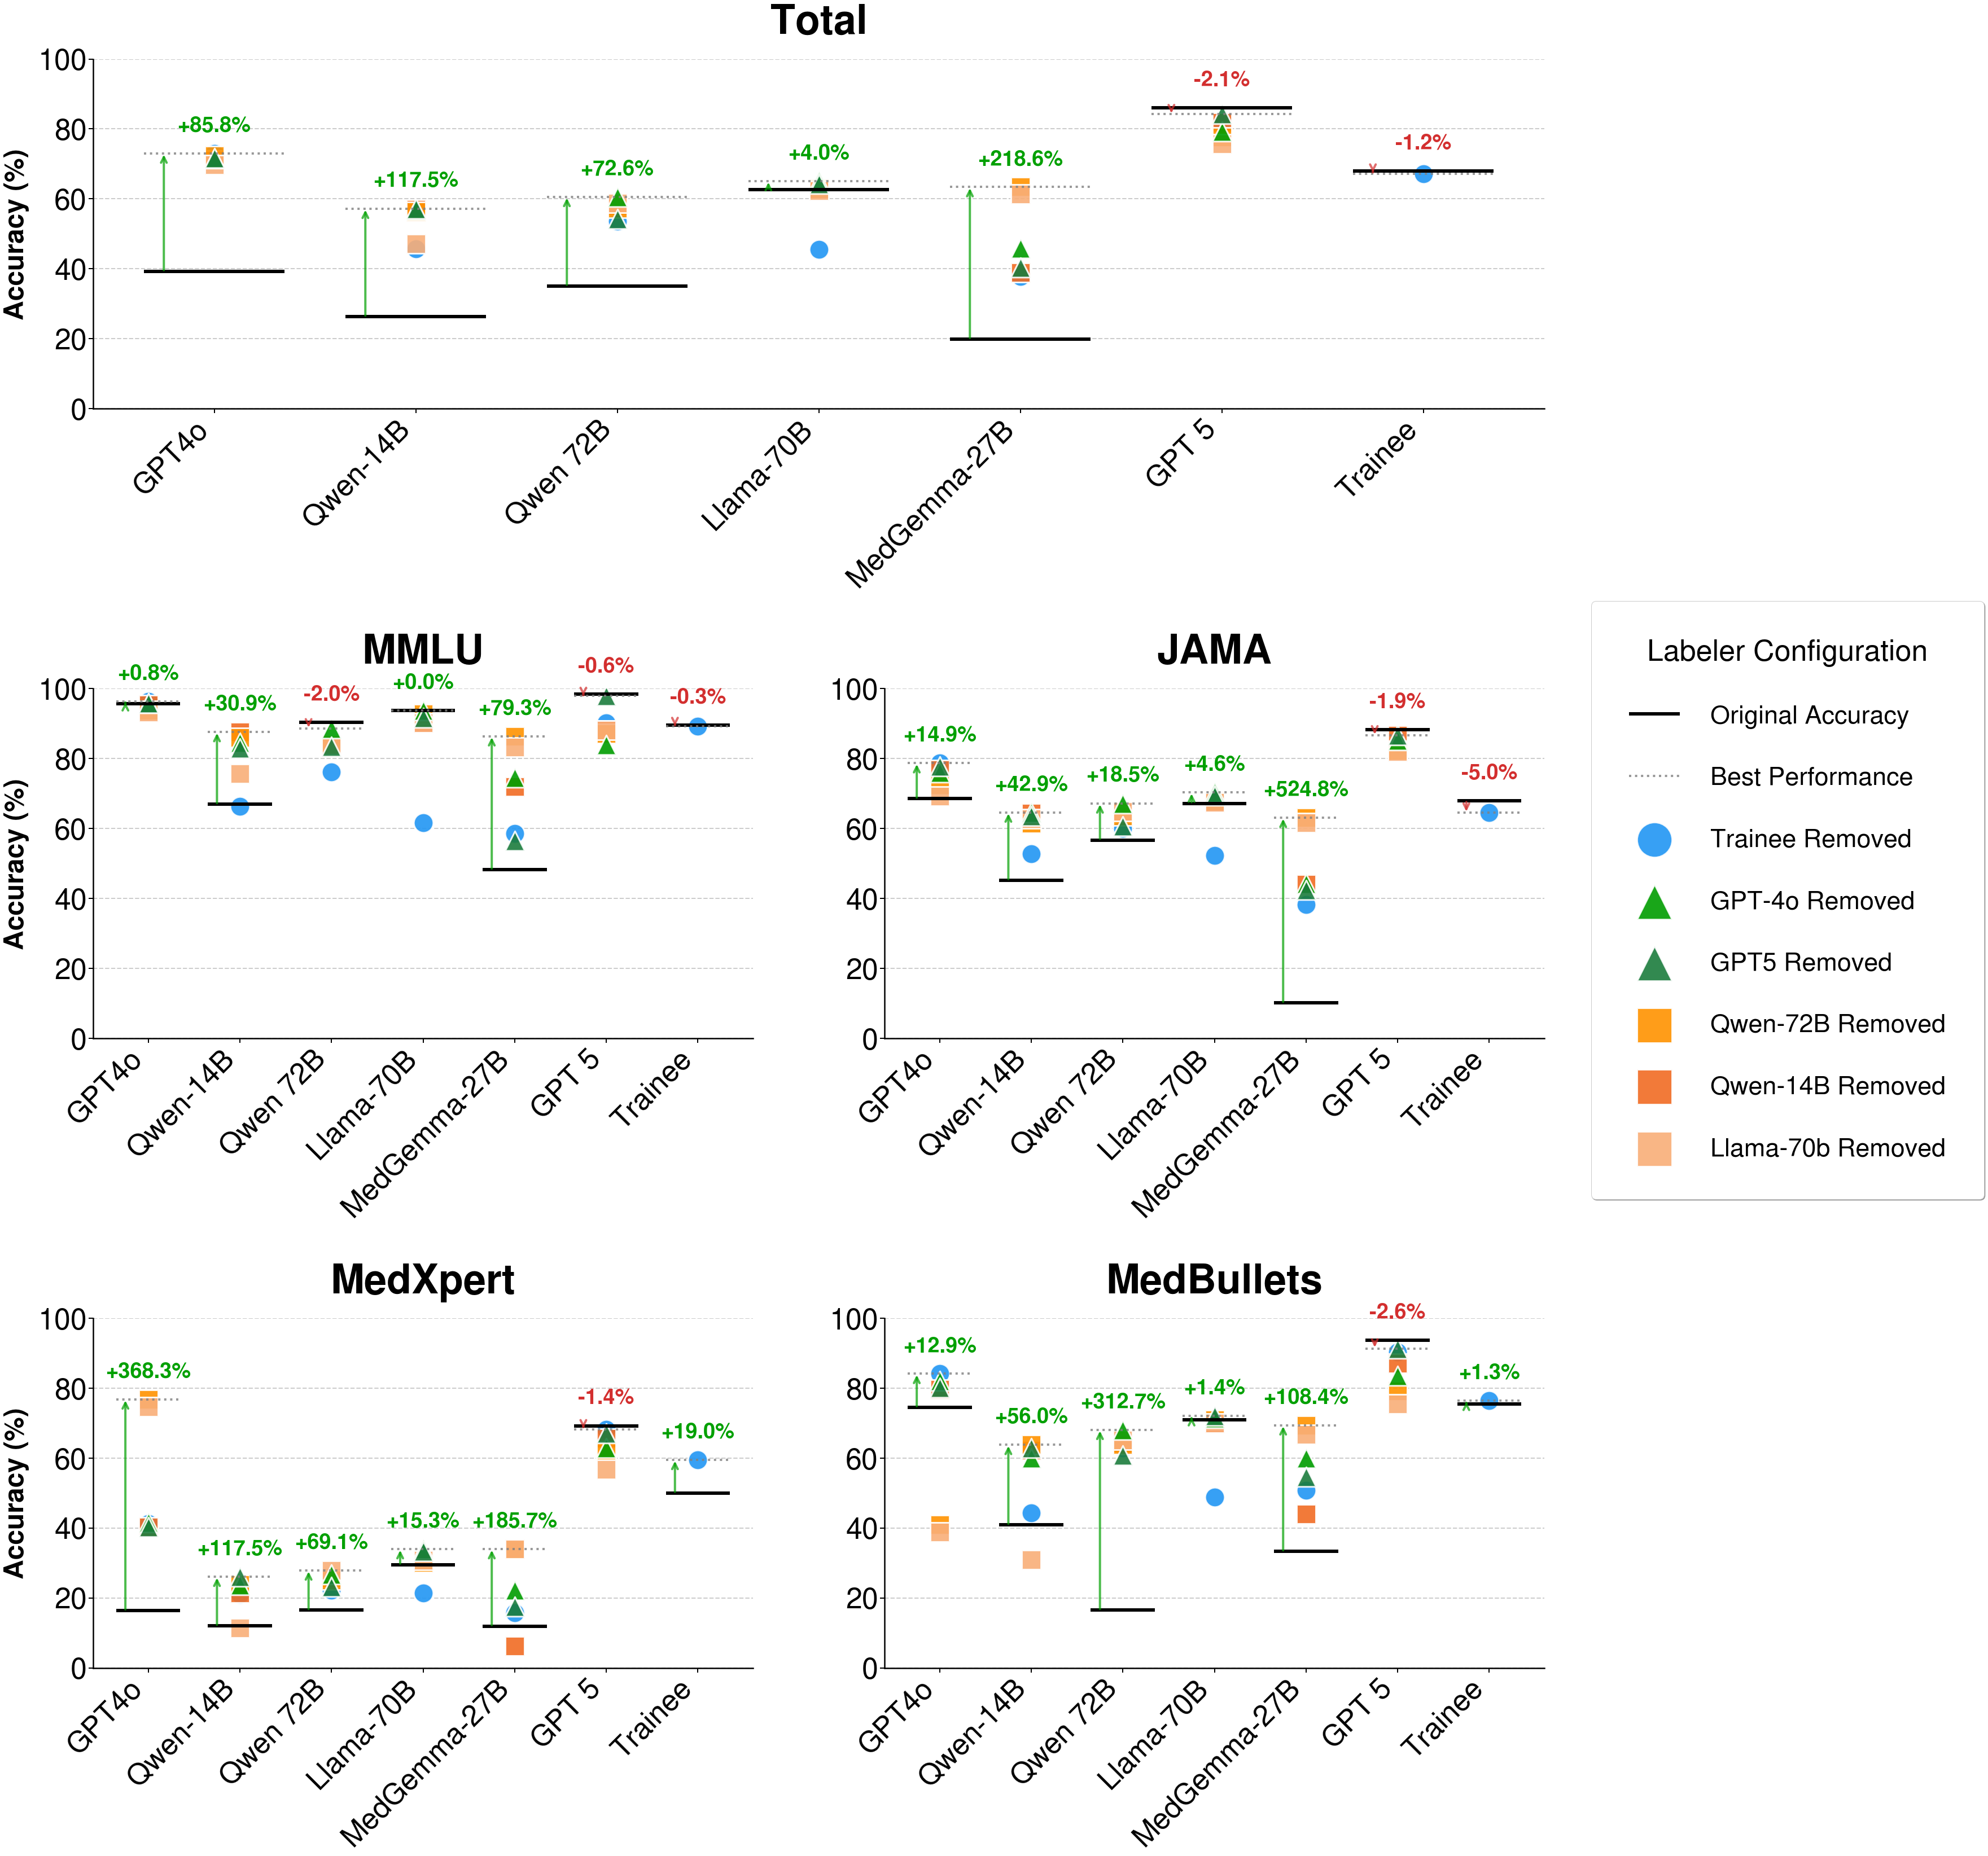

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Robust labeler-column resolution to avoid KeyError across CSV variants
df.columns = df.columns.astype(str).str.strip()
_labeler_candidates = [
    'Low+Irr Labelers',
    'Low + Irr Labelers',
    'Low+IRR Labelers',
    'Low + IRR Labelers',
]
labeler_col = next((c for c in _labeler_candidates if c in df.columns), None)
if labeler_col is None:
    raise KeyError(f"Could not find labeler column. Available columns: {df.columns.tolist()}")
if labeler_col != 'Low+Irr Labelers':
    df = df.rename(columns={labeler_col: 'Low+Irr Labelers'})

# Clean the data first
df['Low+Irr Labelers'] = df['Low+Irr Labelers'].astype(str).str.strip()

# Set style for better aesthetics
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Define colors for each "Low+Irr Labelers" entry
labeler_colors = {
    'Original Accuracy': '#000000',
    'Trainee Removed': '#2196F3',
    'Trainee Removed (248 QAs)': '#2196F3',
    'Qwen-14B Removed': '#f16c23',
    'Qwen-72B Removed': '#ff9200',
    'Llama-70b Removed': '#f9AE78',
    'GPT-4o Removed': '#009d00',
    'GPT5 Removed': '#1b7c3d',
    'MedGemma-27B': '#ECB66C'
}

# Define marker shapes for different labelers
labeler_markers = {
    'Original Accuracy': None,
    'Trainee Removed': 'o',
    'Trainee Removed (248 QAs)': 'o',
    'Qwen-14B Removed': 's',
    'Qwen-72B Removed': 's',
    'Llama-70b Removed': 's',
    'MedGemma-27B Removed': 's',
    'GPT-4o Removed': '^',
    'GPT5 Removed': '^',
}

# Set up the plot with custom layout
fig = plt.figure(figsize=(42, 45))
gs = fig.add_gridspec(3, 2, hspace=0.8, wspace=0.2, 
                       height_ratios=[1, 1, 1])

# Create 5 subplots
axes = [
    fig.add_subplot(gs[0, :]),   # Top row, full width - Total
    fig.add_subplot(gs[1, 0]),   # Middle left - MMLU
    fig.add_subplot(gs[1, 1]),   # Middle right - Jama
    fig.add_subplot(gs[2, 0]),   # Bottom left - MedXpert
    fig.add_subplot(gs[2, 1]),   # Bottom right - Medbullets
]

# Define which column each subplot represents
columns = ['Total', 'MMLU', 'Jama', 'MedXpert', 'Medbullets']
titles = (['Total', '933', 'HardQA', 'Impossible', 'Mean (3 sub.)'] if USE_PHYSICIAN_SUBSET_LABELS else ['Total', 'MMLU', 'JAMA', 'MedXpert', 'MedBullets'])

# Base models to show on x-axis - FIXED to match your data exactly
base_models = ['GPT4o', 'Qwen-14B', 'Qwen 72B', 'Llama-70B', 'MedGemma-27B', 'GPT 5', 'Trainee']

# Plot each subplot
for ax_idx, (ax, col, title) in enumerate(zip(axes, columns, titles)):
    x_positions = np.arange(len(base_models))
    
    # Track which labels we've added to legend
    added_labels = set()
    
    # Track to add legend label only once for best performance line
    best_perf_label_added = False
    
    # For each base model, plot all its labeler variations
    for i, model in enumerate(base_models):
        # Get all rows for this base model
        model_data = df[df['Base Model'] == model]
        
        if len(model_data) == 0:
            continue
        
        # Find the original accuracy (black line value) for this model
        original_acc_row = model_data[model_data['Low+Irr Labelers'] == 'Original Accuracy']
        original_acc_value = original_acc_row[col].values[0] if len(original_acc_row) > 0 else None
        
        # Find the best performance (max value excluding original accuracy)
        other_labelers = model_data[model_data['Low+Irr Labelers'] != 'Original Accuracy']
        if len(other_labelers) > 0:
            best_value = other_labelers[col].max()
        else:
            best_value = None
        
        # Plot each labeler entry
        for _, row in model_data.iterrows():
            labeler = row['Low+Irr Labelers']
            value = row[col]
            color = labeler_colors.get(labeler, '#7f7f7f')
            
            # Only add label if we haven't seen this labeler yet
            label = labeler if labeler not in added_labels else ''
            if label:
                added_labels.add(labeler)
            
            # Plot Original Accuracy as a horizontal line instead of a dot
            if labeler == 'Original Accuracy':
                ax.plot([i - 0.35, i + 0.35], [value, value], 
                       color=color, linewidth=6, solid_capstyle='butt',
                       zorder=3, label=label)
            else:
                # Get the marker shape for this labeler
                marker = labeler_markers.get(labeler, 'o')
                
                # Plot other labelers as dots/triangles/squares
                ax.scatter(i, value, c=color, s=1200, alpha=0.9, 
                          marker=marker, edgecolors='white', linewidth=3, zorder=3,
                          label=label)
        
        # === ADD BEST PERFORMANCE LINE FOR THIS X-AXIS POSITION ===
        if best_value is not None and original_acc_value is not None:
            # Draw grey dotted horizontal line at best performance
            line_label = 'Best Performance' if (ax_idx == 0 and not best_perf_label_added) else ''
            if line_label:
                best_perf_label_added = True
            
            ax.plot([i - 0.35, i + 0.35], [best_value, best_value], 
                   color='#808080', linewidth=4, linestyle=':', 
                   solid_capstyle='butt', zorder=4, label=line_label, alpha=0.8)
            
            # Calculate percentage improvement over original accuracy
            pct_improvement = ((best_value - original_acc_value) / original_acc_value) * 100
            
#             # Add green upward arrow from original to best
#             ax.annotate('', 
#                        xy=(i, best_value), 
#                        xytext=(i, original_acc_value),
#                        arrowprops=dict(arrowstyle='->', color='#00a000', 
#                                      lw=4, mutation_scale=25, alpha=0.7),
#                        zorder=5)
            
            # Determine color based on improvement/decline
            text_color = '#00a000' if pct_improvement >= 0 else '#d32f2f'
            arrow_color = '#00a000' if pct_improvement >= 0 else '#d32f2f'
            
            # Format percentage text with proper sign
            if pct_improvement >= 0:
                pct_text = f'+{pct_improvement:.1f}%'
            else:
                pct_text = f'{pct_improvement:.1f}%'  # Already has minus sign
            
            # Draw arrow slightly to the left to avoid overlapping with dots
            arrow_x = i - 0.25
            ax.annotate('', 
                       xy=(arrow_x, best_value), 
                       xytext=(arrow_x, original_acc_value),
                       arrowprops=dict(arrowstyle='->', color=arrow_color, 
                                     lw=4, mutation_scale=25, alpha=0.7),
                       zorder=5)
            
            # Add percentage text at top center of this x-axis position
            text_y = max(best_value, original_acc_value) + 5
            ax.text(i, text_y,
                   pct_text, 
                   fontsize=38, fontweight='bold', color=text_color,
                   ha='center', va='bottom',
                   zorder=6)
    
    # Formatting
    ax.set_xlim(-0.6, len(base_models) - 0.4)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(base_models, rotation=45, ha='right', fontsize=44, fontweight='500')
    
    # Only show y-axis label for left plots (index 0, 1, 3)
    if ax_idx in [0, 1, 3]:
        ax.set_ylabel('Accuracy (%)', fontsize=48, fontweight='bold', labelpad=15)
        
    ax.set_title(title, fontsize=72, fontweight='bold', pad=45)
    ax.grid(axis='y', alpha=0.4, linewidth=2, color='gray', linestyle='--', zorder=1)
    ax.grid(axis='x', alpha=0, zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=52, width=2, length=8, color='black')
    ax.tick_params(axis='x', labelsize=52, width=2, length=8, color='black')
    
    # Set y-axis limits
    ax.set_ylim(0, 100)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Thicker black spines for left and bottom only
    ax.spines['left'].set_linewidth(2.5)
    ax.spines['left'].set_edgecolor('black')
    ax.spines['bottom'].set_linewidth(2.5)
    ax.spines['bottom'].set_edgecolor('black')

# Create unified legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Reorder legend - add best performance line
legend_order = ['Original Accuracy', 'Best Performance', 'Trainee Removed', 'GPT-4o Removed', 
                'GPT5 Removed', 'Qwen-72B Removed', 'Qwen-14B Removed', 'Llama-70b Removed']
ordered_handles = []
ordered_labels = []
for label in legend_order:
    if label in by_label:
        ordered_labels.append(label)
        ordered_handles.append(by_label[label])

fig.legend(ordered_handles, ordered_labels, 
          loc='center left', bbox_to_anchor=(0.88, 0.5),
          fontsize=36, framealpha=1, markerscale=1.8,
          frameon=True, fancybox=True, shadow=True,
          title='Labeler Configuration', title_fontsize=40,
          labelspacing=1.5, borderpad=1.5, handletextpad=1.2)

plt.subplots_adjust(left=0.01, right=0.86, top=0.96, bottom=0.08)
plt.savefig(paths.FIGURES / 'MedPAIR_Result.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

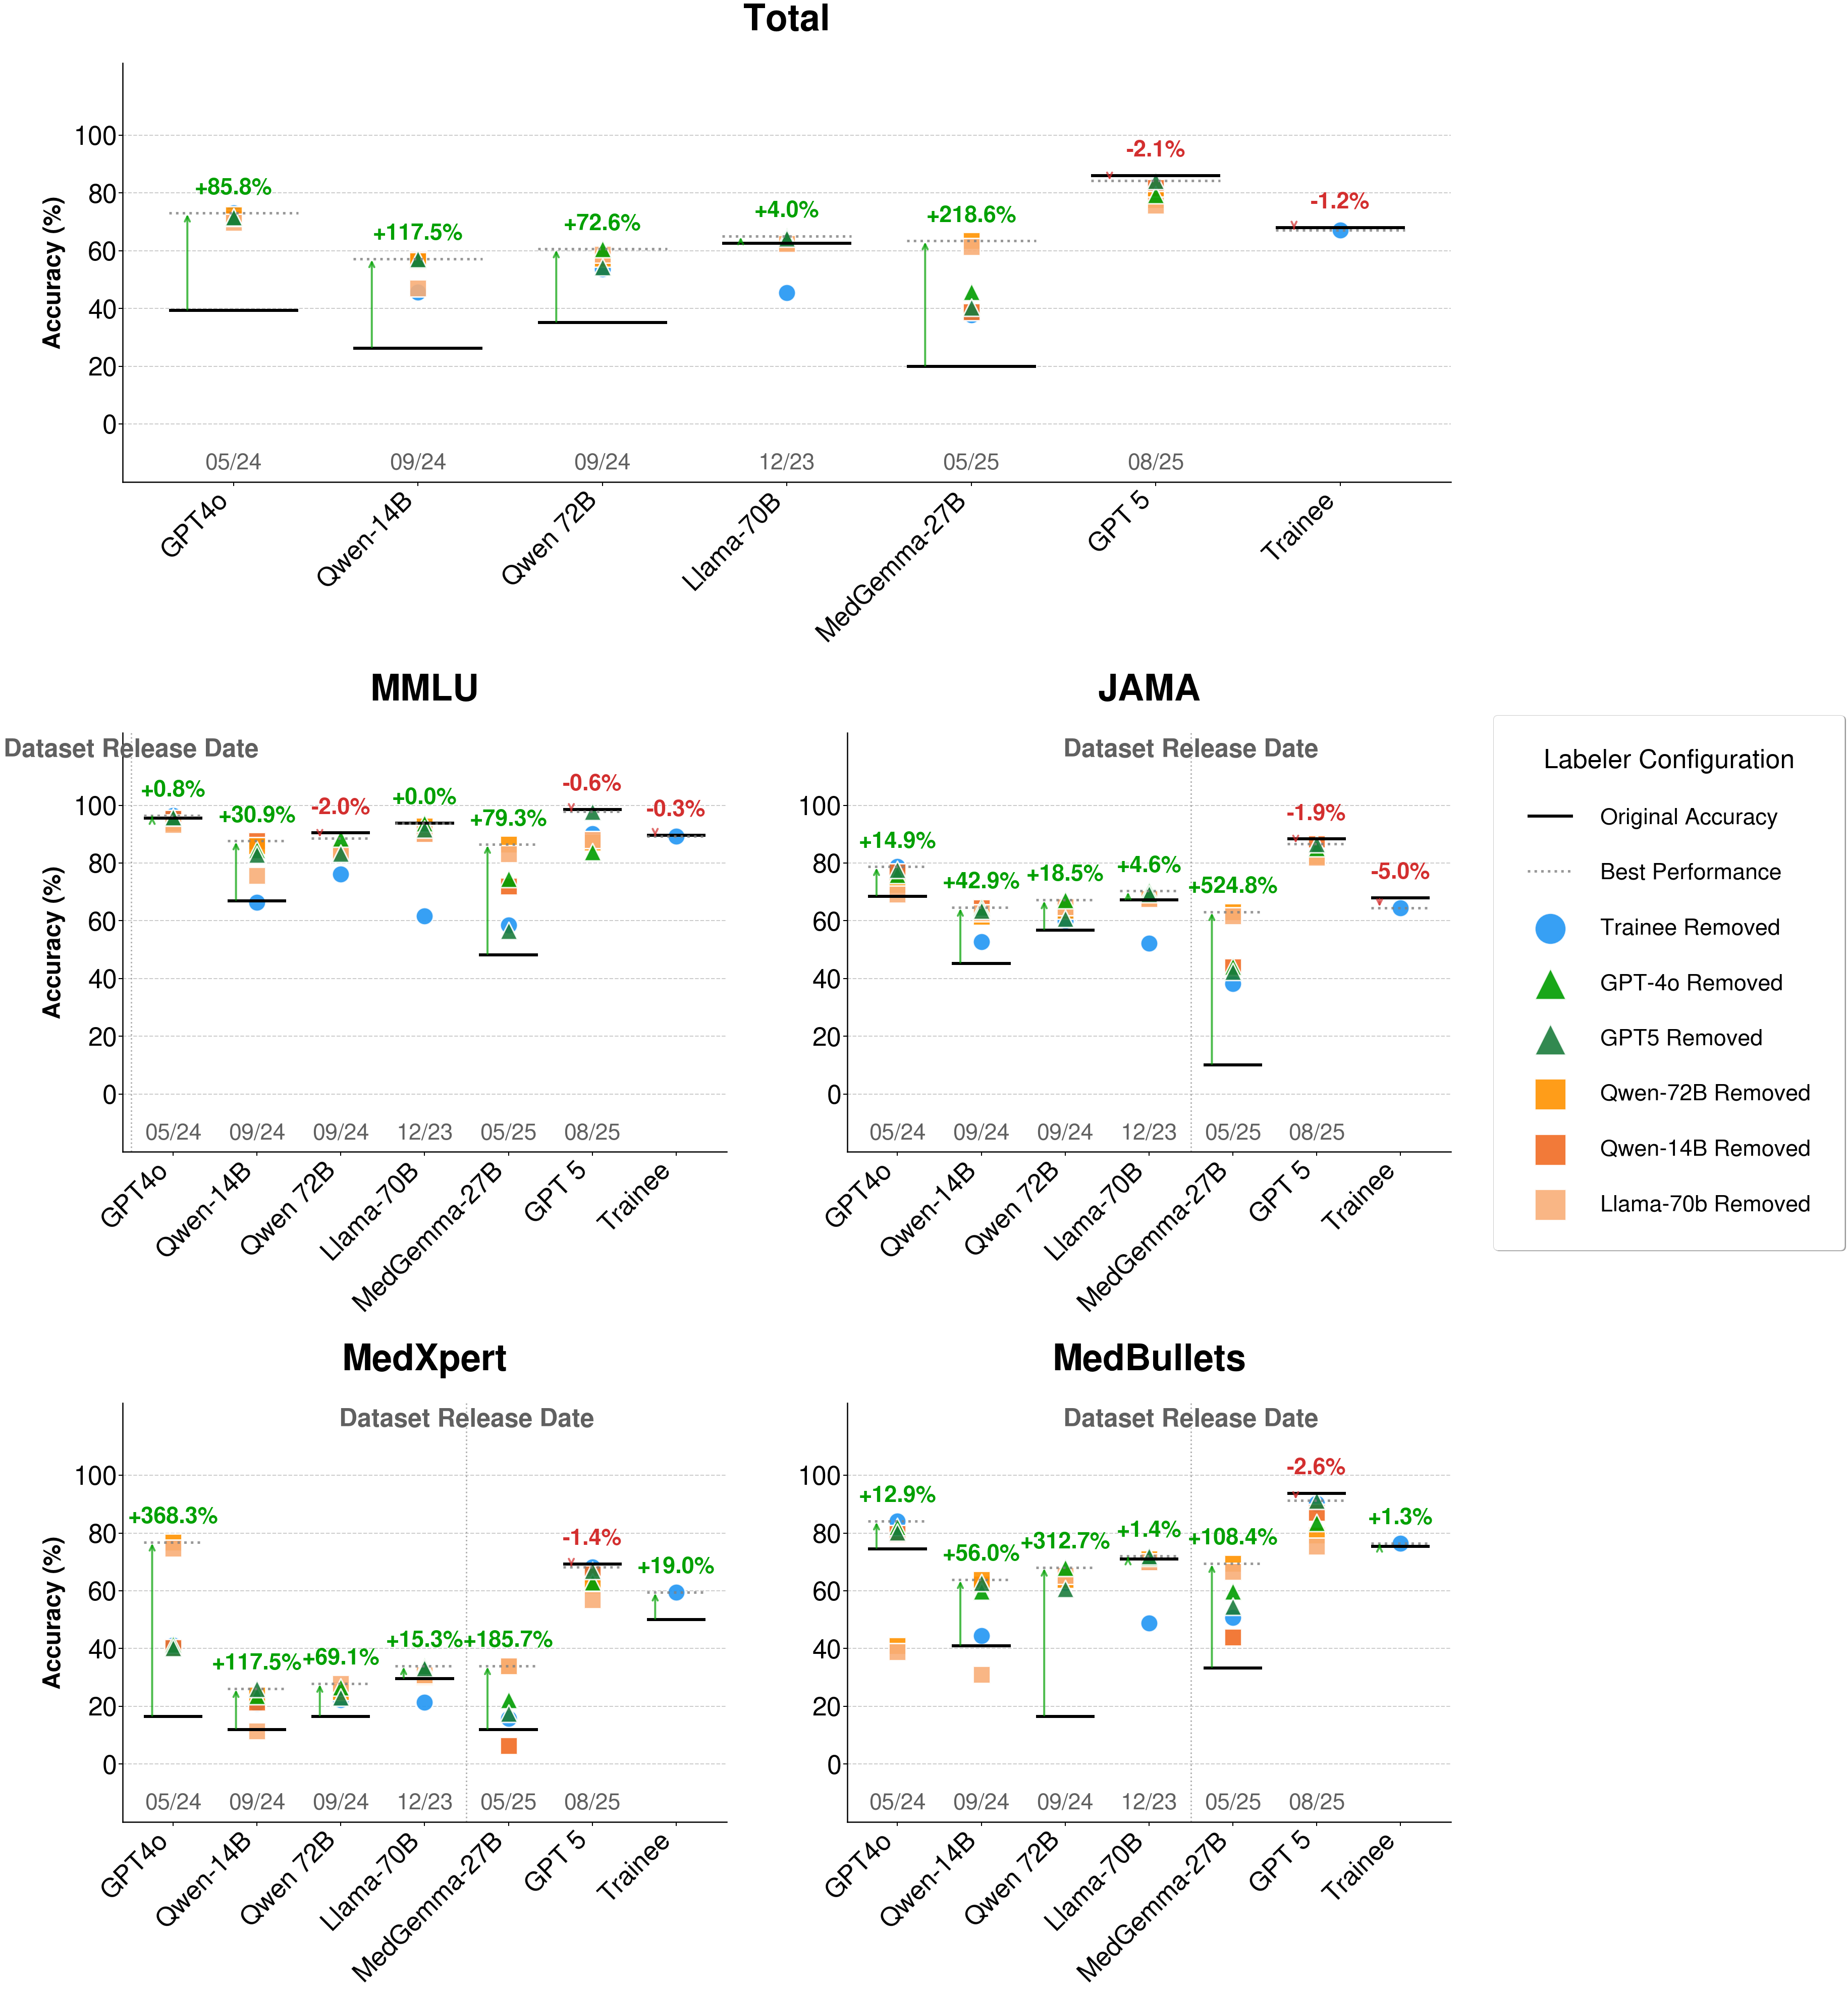

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Robust labeler-column resolution to avoid KeyError across CSV variants
df.columns = df.columns.astype(str).str.strip()
_labeler_candidates = [
    'Low+Irr Labelers',
    'Low + Irr Labelers',
    'Low+IRR Labelers',
    'Low + IRR Labelers',
]
labeler_col = next((c for c in _labeler_candidates if c in df.columns), None)
if labeler_col is None:
    raise KeyError(f"Could not find labeler column. Available columns: {df.columns.tolist()}")
if labeler_col != 'Low+Irr Labelers':
    df = df.rename(columns={labeler_col: 'Low+Irr Labelers'})

# Clean the data first
df['Low+Irr Labelers'] = df['Low+Irr Labelers'].astype(str).str.strip()

# Set style for better aesthetics
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Define colors for each "Low+Irr Labelers" entry
labeler_colors = {
    'Original Accuracy': '#000000',
    'Trainee Removed': '#2196F3',
    'Trainee Removed (248 QAs)': '#2196F3',
    'Qwen-14B Removed': '#f16c23',
    'Qwen-72B Removed': '#ff9200',
    'Llama-70b Removed': '#f9AE78',
    'GPT-4o Removed': '#009d00',
    'GPT5 Removed': '#1b7c3d',
    'MedGemma-27B': '#ECB66C'
}

# Define marker shapes for different labelers
labeler_markers = {
    'Original Accuracy': None,
    'Trainee Removed': 'o',
    'Trainee Removed (248 QAs)': 'o',
    'Qwen-14B Removed': 's',
    'Qwen-72B Removed': 's',
    'Llama-70b Removed': 's',
    'MedGemma-27B Removed': 's',
    'GPT-4o Removed': '^',
    'GPT5 Removed': '^',
}

# Release dates for each model
release_dates = {
    'GPT4o': '05/24',
    'Qwen-14B': '09/24',
    'Qwen 72B': '09/24',
    'Llama-70B': '12/23',
    'MedGemma-27B': '05/25',
    'GPT 5': '08/25',
    'Trainee': '',
    'Physician': ''
}

# Set up the plot with custom layout (Total + 4 datasets)
fig = plt.figure(figsize=(43, 55))
gs = fig.add_gridspec(3, 2, hspace=0.6, wspace=0.2, 
                       height_ratios=[1, 1, 1])

# Create 5 subplots (Total on top, then MMLU, JAMA, MedXpert, MedBullets)
axes = [
    fig.add_subplot(gs[0, :]),   # Top row, full width - Total
    fig.add_subplot(gs[1, 0]),   # MMLU
    fig.add_subplot(gs[1, 1]),   # Jama
    fig.add_subplot(gs[2, 0]),   # MedXpert
    fig.add_subplot(gs[2, 1]),   # Medbullets
]

# Define which column each subplot represents
columns = ['Total', 'MMLU', 'Jama', 'MedXpert', 'Medbullets']
titles = (['Total', '933', 'HardQA', 'Impossible', 'Mean (3 sub.)'] if USE_PHYSICIAN_SUBSET_LABELS else ['Total', 'MMLU', 'JAMA', 'MedXpert', 'MedBullets'])

# Base models to show on x-axis
base_models = ['GPT4o', 'Qwen-14B', 'Qwen 72B', 'Llama-70B', 'MedGemma-27B', 'GPT 5', 'Trainee']

# Plot each subplot
for ax_idx, (ax, col, title) in enumerate(zip(axes, columns, titles)):
    x_positions = np.arange(len(base_models))
    
    # Track which labels we've added to legend
    added_labels = set()
    
    # Track to add legend label only once for best performance line
    best_perf_label_added = False
    
    # For each base model, plot all its labeler variations
    for i, model in enumerate(base_models):
        # Get all rows for this base model
        model_data = df[df['Base Model'] == model]
        
        if len(model_data) == 0:
            continue
        
        # Find the original accuracy (black line value) for this model
        original_acc_row = model_data[model_data['Low+Irr Labelers'] == 'Original Accuracy']
        original_acc_value = original_acc_row[col].values[0] if len(original_acc_row) > 0 else None
        
        # Find the best performance (max value excluding original accuracy)
        other_labelers = model_data[model_data['Low+Irr Labelers'] != 'Original Accuracy']
        best_labeler_name = None
        if len(other_labelers) > 0:
            best_row = other_labelers.loc[other_labelers[col].idxmax()]
            best_value = best_row[col]
            best_labeler_name = best_row['Low+Irr Labelers']
        else:
            best_value = None
        
        # Plot each labeler entry
        for _, row in model_data.iterrows():
            labeler = row['Low+Irr Labelers']
            value = row[col]
            color = labeler_colors.get(labeler, '#7f7f7f')
            
            # Only add label if we haven't seen this labeler yet
            label = labeler if labeler not in added_labels else ''
            if label:
                added_labels.add(labeler)
            
            # Plot Original Accuracy as a horizontal line instead of a dot
            if labeler == 'Original Accuracy':
                ax.plot([i - 0.35, i + 0.35], [value, value], 
                       color=color, linewidth=6, solid_capstyle='butt',
                       zorder=3, label=label)
            else:
                # Get the marker shape for this labeler
                marker = labeler_markers.get(labeler, 'o')
                
                # Plot other labelers as dots/triangles/squares
                ax.scatter(i, value, c=color, s=1200, alpha=0.9, 
                          marker=marker, edgecolors='white', linewidth=3, zorder=3,
                          label=label)
        
        # === ADD BEST PERFORMANCE LINE FOR THIS X-AXIS POSITION ===
        if best_value is not None and original_acc_value is not None:
            # Draw grey dotted horizontal line at best performance
            line_label = 'Best Performance' if (ax_idx == 0 and not best_perf_label_added) else ''
            if line_label:
                best_perf_label_added = True
            
            ax.plot([i - 0.35, i + 0.35], [best_value, best_value], 
                   color='#808080', linewidth=5, linestyle=':', 
                   solid_capstyle='butt', zorder=4, label=line_label, alpha=0.8)
            
            # Calculate percentage improvement over original accuracy
            pct_improvement = ((best_value - original_acc_value) / original_acc_value) * 100
            
            # Determine color based on improvement/decline
            text_color = '#00a000' if pct_improvement >= 0 else '#d32f2f'
            arrow_color = '#00a000' if pct_improvement >= 0 else '#d32f2f'
            
            # Format percentage text with proper sign
            if pct_improvement >= 0:
                pct_text = f'+{pct_improvement:.1f}%'
            else:
                pct_text = f'{pct_improvement:.1f}%'
            
            # Draw arrow slightly to the left to avoid overlapping with dots
            arrow_x = i - 0.25
            ax.annotate('', 
                       xy=(arrow_x, best_value), 
                       xytext=(arrow_x, original_acc_value),
                       arrowprops=dict(arrowstyle='->', color=arrow_color, 
                                     lw=4, mutation_scale=25, alpha=0.7),
                       zorder=5)
            
            # Add percentage text at top center of this x-axis position
            text_y = max(best_value, original_acc_value) + 5
            ax.text(i, text_y,
                   pct_text, 
                   fontsize=45, fontweight='bold', color=text_color,
                   ha='center', va='bottom',
                   zorder=6)
                   
        # === ADD RELEASE DATE BELOW MODEL ===
        if release_dates.get(model, ''):
            ax.text(i, -10,  # Moved lower from -8 to -15
                   release_dates[model], 
                   fontsize=45, fontweight='500', color='#606060',  # Increased from 32 to 38
                   ha='center', va='top',
                   zorder=6)
    
    # === ADD VERTICAL DOTTED LINES WITH LABELS ===
    if (USE_PHYSICIAN_SUBSET_LABELS and title == '933') or (not USE_PHYSICIAN_SUBSET_LABELS and title == 'MMLU'):
        # Add vertical line before GPT4o (which is at position 0)
        ax.axvline(x=-0.5, color='#808080', linewidth=3, linestyle=':', alpha=0.6, zorder=2)
        # Add label for the vertical line
        ax.text(-0.5, 115, 'Dataset Release Date', 
               fontsize=50, fontweight='600', color='#606060',
               ha='center', va='bottom', rotation=0, zorder=6)
    elif (USE_PHYSICIAN_SUBSET_LABELS and title in ['HardQA', 'Impossible', 'Mean (3 sub.)']) or (not USE_PHYSICIAN_SUBSET_LABELS and title in ['JAMA', 'MedXpert', 'MedBullets']):
        # Add vertical line between Llama-70B (position 3) and MedGemma-27B (position 4)
        ax.axvline(x=3.5, color='#808080', linewidth=3, linestyle=':', alpha=0.6, zorder=2)
        # Add label for the vertical line
        ax.text(3.5, 115, 'Dataset Release Date', 
               fontsize=50, fontweight='600', color='#606060',
               ha='center', va='bottom', rotation=0, zorder=6)
    
    # Formatting
    ax.set_xlim(-0.6, len(base_models) - 0.4)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(base_models, rotation=45, ha='right', fontsize=44, fontweight='500')
    
    # Only show y-axis label for left plots (index 0, 2)
    if ax_idx in [0, 1, 3]:
        ax.set_ylabel('Accuracy (%)', fontsize=48, fontweight='bold', labelpad=15)
        
    ax.set_title(title, fontsize=72, fontweight='bold', pad=65)  # Increased pad from 45 to 65
    ax.grid(axis='y', alpha=0.4, linewidth=2, color='gray', linestyle='--', zorder=1)
    ax.grid(axis='x', alpha=0, zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=52, width=2, length=8, color='black')
    ax.tick_params(axis='x', labelsize=52, width=2, length=8, color='black')
    
    # Set y-axis limits with extra space for best labeler name, release date, and vertical line label
    ax.set_ylim(-20, 125)  # Increased upper limit from 110 to 125 to accommodate vertical line labels
    # Finer y-axis ticks (every 10 instead of 0, 50, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Thicker black spines for left and bottom only
    ax.spines['left'].set_linewidth(2.5)
    ax.spines['left'].set_edgecolor('black')
    ax.spines['bottom'].set_linewidth(2.5)
    ax.spines['bottom'].set_edgecolor('black')

# Create unified legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Reorder legend - add best performance line
legend_order = ['Original Accuracy', 'Best Performance', 'Trainee Removed', 'GPT-4o Removed', 
                'GPT5 Removed', 'Qwen-72B Removed', 'Qwen-14B Removed', 'Llama-70b Removed']
ordered_handles = []
ordered_labels = []
for label in legend_order:
    if label in by_label:
        ordered_labels.append(label)
        ordered_handles.append(by_label[label])

fig.legend(ordered_handles, ordered_labels, 
          loc='center left', bbox_to_anchor=(0.88, 0.5),
          fontsize=45, framealpha=1, markerscale=1.8,
          frameon=True, fancybox=True, shadow=True,
          title='Labeler Configuration', title_fontsize=52,
          labelspacing=1.5, borderpad=1.5, handletextpad=1.2)

plt.subplots_adjust(left=0.01, right=0.86, top=0.96, bottom=0.08)
plt.savefig(paths.FIGURES / 'MedPAIR_Result.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Create the data with mean and SD separated
data = {
    'Model': [
        'Qwen-72B (CC)', 'Qwen-72B (SR)',
        'Llama-70B (CC)', 'Llama-70B (SR)',
        'Qwen-14B (CC)', 'Qwen-14B (SR)',
        'MedGemma-27B (SR)',
        'GPT-4o (SR)',
        'GPT-5 (SR)',
        'Physicians (SR)'
    ],
    
    # MMLU
    'MMLU_Mean': [26.9, 72.6, 70.7, 57.4, 56.9, 53.6, 66.1, 50.5, 60.3, 77.1],
    'MMLU_SD': [22.2, 21.2, 24.7, 21.3, 19.6, 23.9, 21.9, 29.4, 17.0, 18.2],
    
    # JAMA
    'JAMA_Mean': [45.5, 69.0, 62.1, 57.5, 59.1, 55.9, 63.1, 45.2, 35.7, 69.2],
    'JAMA_SD': [23.9, 16.7, 22.6, 16.1, 20.1, 18.3, 17.4, 29.3, 18.2, 16.8],
    
    # MedBullets
    'MedBullets_Mean': [49.8, 68.9, 66.6, 52.1, 53.9, 47.7, 61.3, 45.2, 50.2, 72.1],
    'MedBullets_SD': [24.8, 18.7, 23.6, 18.7, 17.8, 20.6, 19.2, 28.4, 11.3, 16.0],
    
    # MedXpertQA
    'MedXpertQA_Mean': [51.8, 69.3, 69.3, 53.2, 51.9, 50.4, 63.3, 52.1, 64.3, 74.1],
    'MedXpertQA_SD': [30.3, 21.3, 27.2, 22.2, 19.9, 24.0, 24.0, 35.4, 12.2, 19.4],
    
    # Overall
    'Overall_Mean': [44.9, 69.6, 65.9, 55.6, 56.2, 52.9, 63.3, 47.7, 48.7, 72.0],
    'Overall_SD': [26.7, 19.0, 24.5, 19.1, 19.8, 21.2, 20.2, 30.9, 20.1, 17.7]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
output_file = str(paths.TABLES / 'model_performance_transposed.csv')
df.to_csv(output_file, index=False)

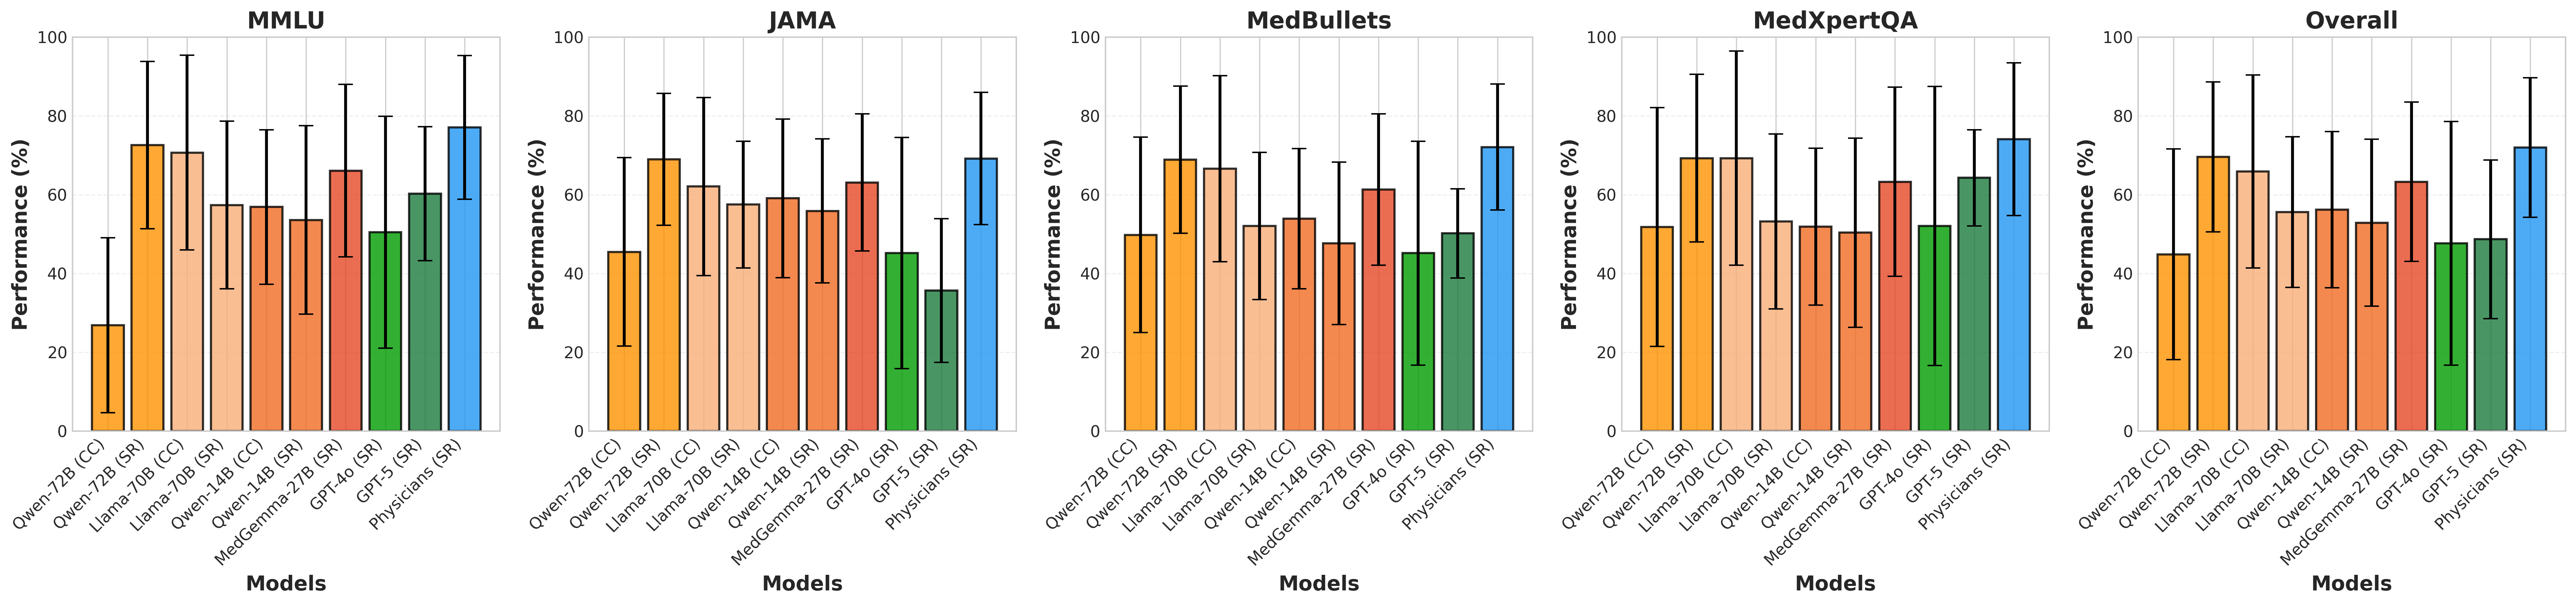

✅ Bar charts created and saved as 'performance_bar_charts.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv(paths.TABLES / "model_performance_transposed.csv")

# Define colors for each model
colors = {
    'GPT-4o (SR)': '#009d00',
    'MedGemma-27B (SR)': '#E64825',
    'GPT-5 (SR)': '#1b7c3d',
    'Qwen-14B (CC)': '#f16c23',
    'Qwen-72B (CC)': '#ff9200',
    'Llama-70B (CC)': '#f9AE78',
    'Qwen-14B (SR)': '#f16c23',
    'Qwen-72B (SR)': '#ff9200',
    'Llama-70B (SR)': '#f9AE78',
    'Physicians (SR)': '#2196F3'
}

# Datasets to plot
datasets = ['MMLU', 'JAMA', 'MedBullets', 'MedXpertQA', 'Overall']

# Create figure with 5 subplots (one for each dataset)
fig, axes = plt.subplots(1, 5, figsize=(25, 6), dpi=300)

# Plot each dataset
for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    # Get mean and SD columns for this dataset
    mean_col = f'{dataset}_Mean'
    sd_col = f'{dataset}_SD'
    
    # Extract data
    models = df['Model'].values
    means = df[mean_col].values
    sds = df[sd_col].values
    
    # Get colors for each model
    bar_colors = [colors.get(model, '#808080') for model in models]
    
    # Create bar positions
    x_pos = np.arange(len(models))
    
    # Create bars with error bars
    bars = ax.bar(x_pos, means, yerr=sds, 
                   color=bar_colors, 
                   capsize=5, 
                   alpha=0.8,
                   edgecolor='black',
                   linewidth=1.5,
                   error_kw={'linewidth': 2, 'ecolor': 'black'})
    
    # Set labels and title
    ax.set_xlabel('Models', fontsize=14, fontweight='bold')
    ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')
    ax.set_title(dataset, fontsize=16, fontweight='bold')
    
    # Set x-axis labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    
    # Set y-axis limits
    ax.set_ylim(0, 100)
    
    # Add grid for readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', labelsize=11)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(paths.FIGURES / 'performance_bar_charts.png', dpi=600, bbox_inches='tight')
plt.show()

print("✅ Bar charts created and saved as 'performance_bar_charts.png'")

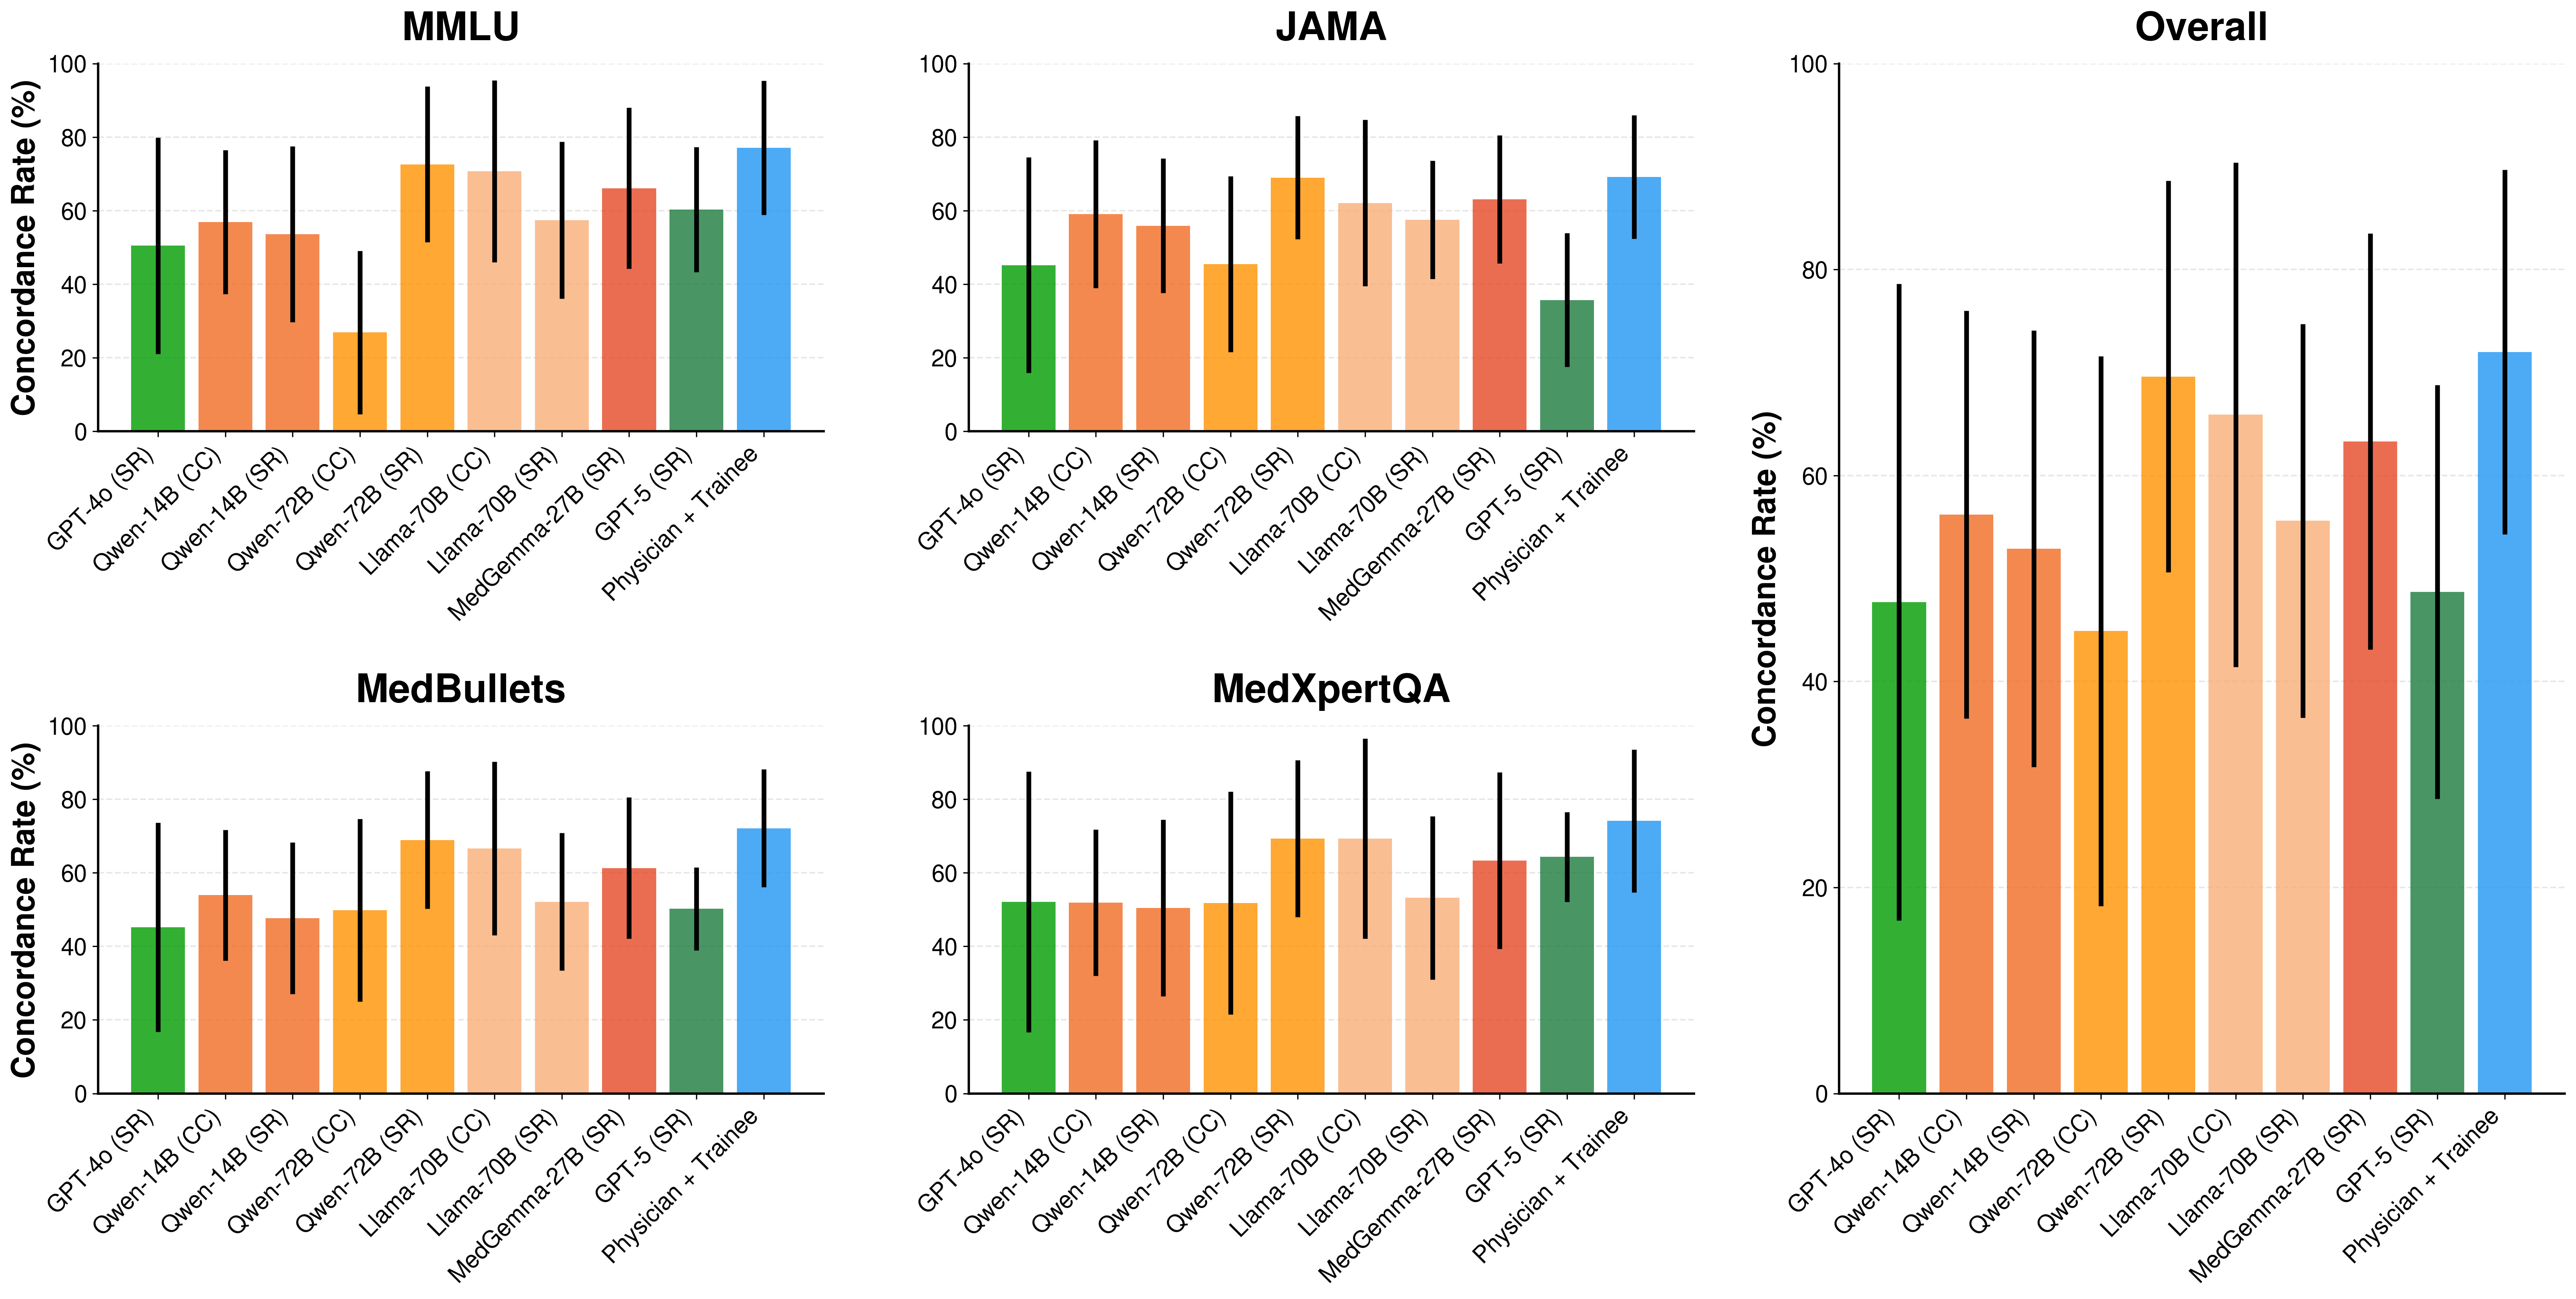

✅ Bar charts created and saved as 'performance_bar_charts.png'


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# Set style for better aesthetics
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Load the data
df = pd.read_csv(paths.TABLES / "model_performance_transposed.csv")

# Define colors for each model
colors = {
    'GPT-4o (SR)': '#009d00',
    'MedGemma-27B (SR)': '#E64825',
    'GPT-5 (SR)': '#1b7c3d',
    'Qwen-14B (CC)': '#f16c23',
    'Qwen-72B (CC)': '#ff9200',
    'Llama-70B (CC)': '#f9AE78',
    'Qwen-14B (SR)': '#f16c23',
    'Qwen-72B (SR)': '#ff9200',
    'Llama-70B (SR)': '#f9AE78',
    'Physician + Trainee': '#2196F3'
}

# Datasets to plot
datasets = ['MMLU', 'JAMA', 'MedBullets', 'MedXpertQA', 'Overall']

# Create figure with custom gridspec for 2x3 layout
fig = plt.figure(figsize=(28, 12), dpi=300)
gs = fig.add_gridspec(2, 3, hspace=0.8, wspace=0.2)

# Create subplots
axes = [
    fig.add_subplot(gs[0, 0]),  # MMLU (top-left)
    fig.add_subplot(gs[0, 1]),  # JAMA (top-middle)
    fig.add_subplot(gs[1, 0]),  # MedBullets (bottom-left)
    fig.add_subplot(gs[1, 1]),  # MedXpertQA (bottom-middle)
    fig.add_subplot(gs[:, 2])   # Overall (spanning both rows, right column)
]

# Normalize display labels so renaming is consistent for text + color lookup
label_alias = {
    'Physicians (SR)': 'Physician + Trainee'
}

base_order = [
    'GPT-4o', 'Qwen-14B', 'Qwen-72B', 'Llama-70B', 'MedGemma-27B', 'GPT-5', 'Physician + Trainee'
]
base_order_index = {name: i for i, name in enumerate(base_order)}


def model_sort_key(model_name):
    normalized = label_alias.get(str(model_name), str(model_name)).strip()
    if normalized == 'Physician + Trainee':
        return (base_order_index['Physician + Trainee'], 0, normalized)

    tag_match = re.search(r'\((CC|SR)\)$', normalized)
    tag = tag_match.group(1) if tag_match else None
    base_name = re.sub(r'\s*\((CC|SR)\)$', '', normalized).strip()

    variant_rank = 0 if tag == 'CC' else 1 if tag == 'SR' else 0
    return (base_order_index.get(base_name, len(base_order)), variant_rank, normalized)


# Plot each dataset
for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    # Get mean and SD columns for this dataset
    mean_col = f'{dataset}_Mean'
    sd_col = f'{dataset}_SD'
    
    # Extract data
    models_raw = df['Model'].astype(str).values
    models = np.array([label_alias.get(m, m) for m in models_raw])
    means = df[mean_col].values
    sds = df[sd_col].values

    # Enforce requested x-axis model order and CC-before-SR within each base model
    order_idx = sorted(range(len(models)), key=lambda i: model_sort_key(models[i]))
    models = models[order_idx]
    means = means[order_idx]
    sds = sds[order_idx]
    
    # Get colors for each model
    bar_colors = [colors.get(model, '#808080') for model in models]
    
    # Create bar positions
    x_pos = np.arange(len(models))
    
    # Create bars with error bars (straight line caps, thicker)
    bars = ax.bar(x_pos, means, yerr=sds, 
                   color=bar_colors, 
                   capsize=0,  # Increased capsize for longer caps
                   alpha=0.8,
                   edgecolor='none',  # Remove black edges
                   linewidth=0,
                   error_kw={'linewidth': 3, 'ecolor': 'black', 'capthick': 3})
    
    # Set labels and title with larger fonts
#     ax.set_xlabel('Models', fontsize=20, fontweight='bold')
    # Remove y-label for the second column (top-middle and bottom-middle)
    if idx not in (1, 3):
        ax.set_ylabel('Concordance Rate (%)', fontsize=20, fontweight='bold')
    ax.set_title(dataset, fontsize=25, fontweight='bold', pad=15)
    
    # Set x-axis labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=14)
    
    # Set y-axis limits
    ax.set_ylim(0, 100)
    
    # Add grid for readability
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
    ax.set_axisbelow(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', labelsize=15)
    
    # Remove spines (outer black layers)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

# Save figure
plt.savefig(paths.FIGURES / 'performance_bar_charts.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Bar charts created and saved as 'performance_bar_charts.png'")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import combinations

# Load the data
df = pd.read_csv(paths.TABLES / "model_performance_transposed.csv")

# Set style for better aesthetics
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Define colors for each dataset
dataset_colors = {
    'MMLU': '#3498db',
    'JAMA': '#e74c3c',
    'MedBullets': '#2ecc71',
    'MedXpertQA': '#f39c12',
    'Overall': '#9b59b6'
}

# Define model colors (for consistency)
model_colors = {
    'GPT-4o (SR)': '#009d00',
    'MedGemma-27B (SR)': '#E64825',
    'GPT-5 (SR)': '#1b7c3d',
    'Qwen-14B (CC)': '#f16c23',
    'Qwen-72B (CC)': '#ff9200',
    'Llama-70B (CC)': '#f9AE78',
    'Qwen-14B (SR)': '#f16c23',
    'Qwen-72B (SR)': '#ff9200',
    'Llama-70B (SR)': '#f9AE78',
    'Physicians (SR)': '#2196F3'
}

# Datasets
datasets = ['MMLU', 'JAMA', 'MedBullets', 'MedXpertQA', 'Overall']

# Reorder models: Qwen-72B (CC & SR), Llama-70B (CC & SR), Qwen-14B (CC & SR), then rest
model_order = [
    'Qwen-72B (CC)',
    'Qwen-72B (SR)',
    'Llama-70B (CC)',
    'Llama-70B (SR)',
    'Qwen-14B (CC)',
    'Qwen-14B (SR)',
    'MedGemma-27B (SR)',
    'GPT-4o (SR)',
    'GPT-5 (SR)',
    'Physicians (SR)'
]

# Reorder dataframe
df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)
df = df.sort_values('Model')
models = df['Model'].values

# ===================================================================
# STATISTICAL SIGNIFICANCE CALCULATION
# ===================================================================
def calculate_pairwise_significance(means, sds, n_samples=100):
    """
    Calculate pairwise statistical significance using t-tests
    Assumes normal distribution based on mean and SD
    n_samples: assumed sample size (adjust based on your actual data)
    """
    p_values = {}
    
    for i, j in combinations(range(len(means)), 2):
        # Simulate data from normal distribution
        data_i = np.random.normal(means[i], sds[i], n_samples)
        data_j = np.random.normal(means[j], sds[j], n_samples)
        
        # Perform independent t-test
        t_stat, p_val = stats.ttest_ind(data_i, data_j)
        p_values[(i, j)] = p_val
    
    return p_values

def get_significance_symbol(p_value):
    """Convert p-value to significance symbol"""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# ===================================================================
# PLOTTING
# ===================================================================
fig, axes = plt.subplots(2, 5, figsize=(35, 20), dpi=300)
axes = axes.flatten()

# Store significance results
significance_results = {}

for idx, model in enumerate(models):
    ax = axes[idx]
    
    # Extract data for this model
    means = []
    sds = []
    for dataset in datasets:
        mean_col = f'{dataset}_Mean'
        sd_col = f'{dataset}_SD'
        means.append(df.loc[df['Model'] == model, mean_col].values[0])
        sds.append(df.loc[df['Model'] == model, sd_col].values[0])
    
    # Calculate statistical significance
    p_values = calculate_pairwise_significance(means, sds)
    significance_results[model] = p_values
    
    # Get colors for each dataset
    bar_colors = [dataset_colors[ds] for ds in datasets]
    
    # Create bar positions
    x_pos = np.arange(len(datasets))
    
    # Create bars with error bars (no caps, just vertical lines)
    bars = ax.bar(x_pos, means, yerr=sds, 
                   color=bar_colors, 
                   capsize=0,  # Remove the T caps
                   alpha=0.85,
                   edgecolor='black',
                   linewidth=2,
                   error_kw={'linewidth': 5, 'ecolor': 'black'})
    
    # Set ylabel only for leftmost plots
    if idx % 5 == 0:
        ax.set_ylabel('Concordance Rate (%)', fontsize=35)
    
    # Set title with black color
    ax.set_title(model, fontsize=39, pad=20, color='black')
    
    # Set x-axis labels for all plots
    ax.set_xticks(x_pos)
    ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=35)
    
    # Set y-axis limits
    ax.set_ylim(0, 100)
    
    # Add grid for readability
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)
    ax.set_axisbelow(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', labelsize=40, width=2, length=6)
    
    # Thicker spines
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(paths.FIGURES / 'performance_by_model.png', dpi=600, bbox_inches='tight')
plt.show()

print("✅ Charts saved as 'performance_by_model.png'")

# ===================================================================
# PRINT STATISTICAL SIGNIFICANCE RESULTS
# ===================================================================
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE RESULTS (Pairwise Comparisons)")
print("="*80)
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("="*80)

for model, p_vals in significance_results.items():
    print(f"\n{model}:")
    print("-" * 60)
    for (i, j), p_val in p_vals.items():
        sig_symbol = get_significance_symbol(p_val)
        print(f"  {datasets[i]:15} vs {datasets[j]:15} | p={p_val:.4f} | {sig_symbol}")

# ===================================================================
# SUMMARY TABLE OF SIGNIFICANT DIFFERENCES
# ===================================================================
print("\n" + "="*80)
print("SUMMARY: Significant Differences (p < 0.05) per Model")
print("="*80)

for model, p_vals in significance_results.items():
    sig_pairs = [(datasets[i], datasets[j], p_val) 
                 for (i, j), p_val in p_vals.items() if p_val < 0.05]
    
    print(f"\n{model}:")
    if sig_pairs:
        for ds1, ds2, p_val in sig_pairs:
            print(f"  ✓ {ds1} ≠ {ds2} (p={p_val:.4f})")
    else:
        print("  No significant differences found")

print("\n" + "="*80)
print("NOTE: These p-values are estimated assuming n=100 samples per dataset.")
print("For more accurate results, use your actual sample sizes and raw data.")
print("="*80)

✅ Charts saved as 'performance_by_model.png'

STATISTICAL SIGNIFICANCE RESULTS (Pairwise Comparisons)
Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant

Qwen-72B (CC):
------------------------------------------------------------
  MMLU            vs JAMA            | p=0.0000 | ***
  MMLU            vs MedBullets      | p=0.0000 | ***
  MMLU            vs MedXpertQA      | p=0.0000 | ***
  MMLU            vs Overall         | p=0.0000 | ***
  JAMA            vs MedBullets      | p=0.1452 | ns
  JAMA            vs MedXpertQA      | p=0.0293 | *
  JAMA            vs Overall         | p=0.1985 | ns
  MedBullets      vs MedXpertQA      | p=0.2698 | ns
  MedBullets      vs Overall         | p=0.1159 | ns
  MedXpertQA      vs Overall         | p=0.0090 | **

Qwen-72B (SR):
------------------------------------------------------------
  MMLU            vs JAMA            | p=0.6686 | ns
  MMLU            vs MedBullets      | p=0.6282 | ns
  MMLU            vs MedXpert

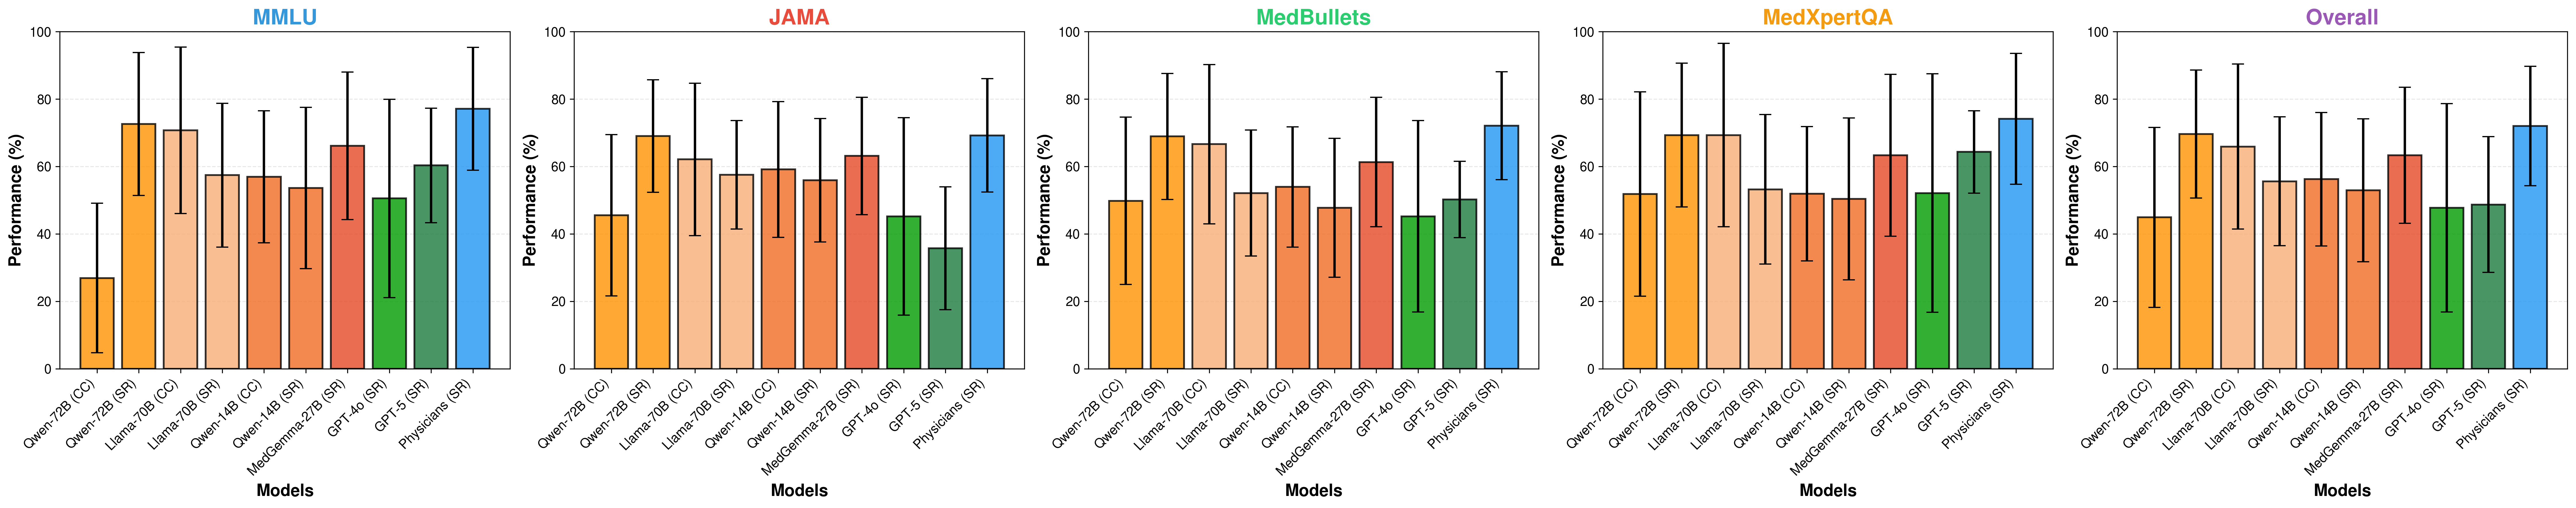

✅ Part 2: Charts by dataset saved as 'performance_by_dataset.png'

📊 Total charts created: 10 models + 5 datasets = 15 charts


In [ ]:
# ===================================================================
# PART 2: One chart per dataset (showing all models)
# ===================================================================
fig2, axes2 = plt.subplots(1, 5, figsize=(30, 6), dpi=300)

for idx, dataset in enumerate(datasets):
    ax = axes2[idx]
    
    # Get mean and SD columns for this dataset
    mean_col = f'{dataset}_Mean'
    sd_col = f'{dataset}_SD'
    
    # Extract data
    model_names = df['Model'].values
    means = df[mean_col].values
    sds = df[sd_col].values
    
    # Get colors for each model
    bar_colors = [model_colors.get(model, '#808080') for model in model_names]
    
    # Create bar positions
    x_pos = np.arange(len(model_names))
    
    # Create bars with error bars
    bars = ax.bar(x_pos, means, yerr=sds, 
                   color=bar_colors, 
                   capsize=5, 
                   alpha=0.8,
                   edgecolor='black',
                   linewidth=1.5,
                   error_kw={'linewidth': 2, 'ecolor': 'black'})
    
    # Set labels and title
    ax.set_xlabel('Models', fontsize=14, fontweight='bold')
    ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')
    ax.set_title(dataset, fontsize=18, fontweight='bold',
                 color=dataset_colors[dataset])
    
    # Set x-axis labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    
    # Set y-axis limits
    ax.set_ylim(0, 100)
    
    # Add grid for readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Increase tick label size
    ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig(paths.FIGURES / 'performance_by_dataset.png', dpi=600, bbox_inches='tight')
plt.show()

print("✅ Part 2: Charts by dataset saved as 'performance_by_dataset.png'")
print("\n📊 Total charts created: 10 models + 5 datasets = 15 charts")